In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '6'
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer, GPTNeoForCausalLM
from torchvision import transforms
from PIL import Image
import timm
from typing import List, Union, Optional
from dataclasses import dataclass
from PIL import Image
import matplotlib.pyplot as plt
# --- Configuration ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {DEVICE}")

Running on cuda


In [2]:
@dataclass
class FrozenConfig:
    vision_encoder_name: str = "resnet50"
    language_model_name: str = "gpt2-large"
    visual_prefix_length: int = 2
    vision_hidden_dim: int = 2048
    lm_hidden_dim: int = 1280

class VisionEncoder(nn.Module):
    def __init__(self, config: FrozenConfig):
        super().__init__()
        self.config = config
        self.backbone = timm.create_model(
            config.vision_encoder_name, pretrained=False, num_classes=0, global_pool=''
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projection = nn.Linear(config.vision_hidden_dim, config.visual_prefix_length * config.lm_hidden_dim)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)
        features = self.pool(features).flatten(1)
        prefix = self.projection(features)
        return prefix.view(-1, self.config.visual_prefix_length, self.config.lm_hidden_dim)

class FrozenModel(nn.Module):
    def __init__(self, config: FrozenConfig):
        super().__init__()
        self.config = config
        self.vision_encoder = VisionEncoder(config)
        if "gpt-neo" in config.language_model_name.lower():
            self.language_model = GPTNeoForCausalLM.from_pretrained(config.language_model_name)
        else:
            self.language_model = GPT2LMHeadModel.from_pretrained(config.language_model_name)

    def get_input_embeddings(self):
        return self.language_model.get_input_embeddings()

In [3]:
# --- Load Model ---
CHECKPOINT_PATH = "frozen_checkpoints/frozen_checkpoint_epoch1.pt" # UPDATE THIS to your actual checkpoint

config = FrozenConfig()
print(f"Initializing model ({config.language_model_name})...")
tokenizer = GPT2Tokenizer.from_pretrained(config.language_model_name)
model = FrozenModel(config)

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading weights from {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    # Load trained vision encoder weights
    if 'vision_encoder_state_dict' in checkpoint:
         model.vision_encoder.load_state_dict(checkpoint['vision_encoder_state_dict'])
    else:
        model.load_state_dict(checkpoint) # Fallback for full model checkpoints
        
    model.to(DEVICE)
    model.eval()
    print("✓ Model loaded successfully.")
else:
    print(f"⚠️ WARNING: Checkpoint not found at {CHECKPOINT_PATH}. Using random vision weights.")
    model.to(DEVICE)
    model.eval()

Initializing model (gpt2-large)...
Loading weights from frozen_checkpoints/frozen_checkpoint_epoch1.pt...


/tmp/ipykernel_16761/1674785254.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


✓ Model loaded successfully.


In [4]:
def generate_from_interleaved(
    model: FrozenModel,
    tokenizer: GPT2Tokenizer,
    prompt_items: List[Union[str, Image.Image]],
    max_new_tokens: int = 80,
    temperature: float = 0.0, # 0.0 for greedy decoding
    device: str = DEVICE
) -> str:
    """
    Generates text from a mixed sequence of images and text.
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    embeddings_list = []
    with torch.no_grad():
        for item in prompt_items:
            if isinstance(item, Image.Image):
                img_tensor = transform(item).unsqueeze(0).to(device)
                # Corrected: use vision_encoder directly
                visual_prefix = model.vision_encoder(img_tensor)
                embeddings_list.append(visual_prefix)
            elif isinstance(item, str):
                tokens = tokenizer(item, return_tensors="pt", add_special_tokens=False).input_ids.to(device)
                # Corrected: generic way to get embeddings
                text_embeds = model.get_input_embeddings()(tokens)
                embeddings_list.append(text_embeds)

        inputs_embeds = torch.cat(embeddings_list, dim=1)
        generated_tokens = []

        for _ in range(max_new_tokens):
            # Corrected: use language_model attribute
            outputs = model.language_model(inputs_embeds=inputs_embeds)
            next_token_logits = outputs.logits[:, -1, :]
            
            if temperature == 0:
                next_token_id = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)
            else:
                next_token_logits = next_token_logits / temperature
                probs = F.softmax(next_token_logits, dim=-1)
                next_token_id = torch.multinomial(probs, num_samples=1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break
                
            generated_tokens.append(next_token_id.item())
            next_token_embed = model.get_input_embeddings()(next_token_id)
            inputs_embeds = torch.cat([inputs_embeds, next_token_embed], dim=1)

    return tokenizer.decode(generated_tokens, skip_special_tokens=True)

In [5]:
# Ensure you have these images or update paths
try:
    img_phone = Image.open("demo_images/car_2.jpg").convert("RGB")
    
    prompt = [img_phone, "Question: What is this object? Answer:"]
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=20)
    print(f"Output: {output}")
    
except FileNotFoundError as e:
    print(f"Error loading test images: {e}")
    print("Please ensure 'demo_images/' folder exists with sample images.")

Output:  It is a mountain . . . and it is the highest mountain in the world . . . and


In [10]:
# --- Setup for VQA Test ---
# Ensure you have these images in your demo_images/ folder, or change paths accordingly.
# You can download random images from the internet for: microscope, car, phone, plane.
img_microscope = Image.open("demo_images/microscope.jpg").convert("RGB")
img_microscope_2 = Image.open("demo_images/microscope.jpg").convert("RGB")
img_microscope_3 = Image.open("demo_images/microscope.jpg").convert("RGB")
img_microscope_4 = Image.open("demo_images/microscope.jpg").convert("RGB")
img_lion = Image.open("demo_images/lion.jpg").convert("RGB")
img_lion_2 = Image.open("demo_images/lion_2.jpg").convert("RGB")
img_lion_3 = Image.open("demo_images/lion_3.jpg").convert("RGB")
img_lion_4 = Image.open("demo_images/lion_4.jpg").convert("RGB")
img_cat = Image.open("images/cat_1.jpg").convert("RGB")
img_cat_2 = Image.open("images/cat_2.jpg").convert("RGB")
img_cat_3 = Image.open("images/cat_3.jpg").convert("RGB")
img_cat_4 = Image.open("images/cat_4.jpg").convert("RGB")
img_dog = Image.open("images/dog_1.jpg").convert("RGB")
img_dog_2 = Image.open("images/dog_2.jpg").convert("RGB")
img_dog_3 = Image.open("images/dog_3.jpg").convert("RGB")
img_dog_4 = Image.open("images/dog_4.jpg").convert("RGB")
img_car = Image.open("images/car_1.jpg").convert("RGB")
img_car_2 = Image.open("images/car_2.jpg").convert("RGB")
img_car_3 = Image.open("images/car_3.jpg").convert("RGB")
img_car_4 = Image.open("images/car_4.jpg").convert("RGB")
img_phone = Image.open("images/phone_1.jpg").convert("RGB")
img_phone_2 = Image.open("images/phone_2.jpg").convert("RGB")
img_phone_3 = Image.open("images/phone_3.jpg").convert("RGB")
img_phone_4 = Image.open("images/phone_4.jpg").convert("RGB")
img_plane = Image.open("images/plane_1.jpg").convert("RGB")
img_plane_2 = Image.open("images/plane_2.jpg").convert("RGB")
img_plane_3 = Image.open("images/plane_3.jpg").convert("RGB")
img_plane_4 = Image.open("images/plane_4.jpg").convert("RGB")

--- Zero-shot VQA ---
Question: What is this object called? 
Prediction:   the phone .
Question: What is this object called?
Answer:  the phone .
Question: What is this object called?
Answer:  the phone .
Question: What is this object called?
Answer:  the phone .
Question: What is this object called?
Answer:  the phone .
Question: What is this object called?
Answer:  the phone .
Question: What is this object called?




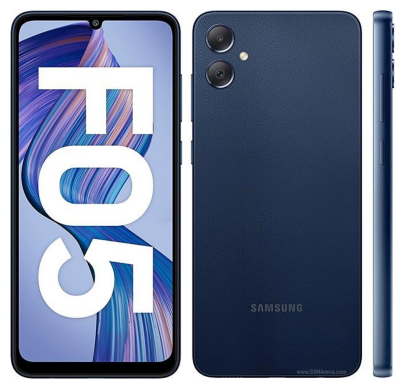

In [13]:

# 1. Zero-shot Baseline (often fails or just captions)
image = img_phone_2
print("--- Zero-shot VQA ---")
print("Question: What is this object called? ")

prompt_0shot = [
    image,
    "Question: What is this object called?\nAnswer:"
]
output_0shot = generate_from_interleaved(model, tokenizer, prompt_0shot, max_new_tokens=100, temperature=0.0)
print(f"Prediction: {output_0shot}\n")
plt.imshow(image)
plt.axis("off")
plt.show()

In [14]:
# 2. Few-shot VQA (Priming with 3 examples)
print("--- Few-shot VQA (3-shot) ---")
prompt_3shot = [
    # # Shot 1
    img_microscope_2, "Question: Who invented this object?\nAnswer: This is a microscope invented by Zacharias Janssen.\n",
    # Shot 2
    img_car_2, "Question: Who invented this object?\nAnswer: This is a car invented by Karl Benz.\n",
    # Shot 3
    img_plane_2, "Question: Who invented this object?\nAnswer: This is a plane invented by  Wright Brothers.\n",
    # Target Query
    img_phone_3, "Question: Who invented this object?\nAnswer:",
]

# We use temperature=0.0 for greedy decoding to get the most likely answer
output_3shot = generate_from_interleaved(model, tokenizer, prompt_3shot, max_new_tokens=20, temperature=0.0)
print(f"Prediction: {output_3shot}")

--- Few-shot VQA (3-shot) ---
Prediction:  This is a car invented by Henry Ford .
Question: Who invented this object?
Answer:


In [16]:
# --- Setup for Concept Binding Test ---

# Define nonsense words
X_WORD = "dax"
Y_WORD = "blicket"

print(f"--- Fast Concept Binding Test ---")
# print(f"Teaching: First Object = {X_WORD}, 2nd Object = {Y_WORD}\n")

prompt_binding = [
    # Teach the model the new words
    img_dog_2, f" This is a {Y_WORD}.\n",
    img_lion, f" This is a {X_WORD}.\n",
    # img_cat_4, f" This is a {Z_WORD}.\n",

    # Query with a new, unseen image of a cat
    img_dog_3, " This is a \n"
]

# Generate
output_binding = generate_from_interleaved(model, tokenizer, prompt_binding, max_new_tokens=10, temperature=0.0)
# print(f"Query Image: Cat")
print(f"Prediction: {output_binding.strip()}")
# Desired output: "dax" (or "dax.")

--- Fast Concept Binding Test ---
Prediction: This is a dax. This is a
